In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
filepath ="/content/drive/MyDrive/Colab Notebooks/PGDBA-Project"

In [4]:
!pip install python_speech_features

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for python_speech_features: filename=python_speech_features-0.6-py3-none-any.whl size=5870 sha256=0679241ac167565cc49747e8c6ee6abde8e2803bafce9c00d9cc89b901a31bb6
  Stored in directory: /root/.cache/pip/wheels/5a/9e/68/30bad9462b3926c29e315df16b562216d12bdc215f4d240294
Successfully built python_speech_features


In [ ]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from python_speech_features import mfcc, logfbank
from tensorflow.keras import models, layers,utils
from sklearn.utils.class_weight import compute_class_weight
import pickle
from config import AudioConfig

In [6]:
def build_rand_feat():
  X=[]
  y=[]
  mn,mx= float('inf'),-float('inf') #9223372999,-9223372999
  for _ in tqdm(range(n_samples)):
    rand_class=np.random.choice(class_dist.index,p=prob_dist)
    file=np.random.choice(df[df.label==rand_class].index)
    rate,wav=wavfile.read("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/V2/clean_train/"+file)
    label=df.at[file,'label']
    rand_index=np.random.randint(0,wav.shape[0]-config.step)
    sample=wav[rand_index:rand_index+config.step]
    X_sample=mfcc(sample,rate,numcep=config.nfeat,nfilt=config.nfilt,nfft=config.nfft)
    mn=min(np.amin(X_sample),mn)
    mx=max(np.amax(X_sample),mx)
    X.append(X_sample)
    y.append(classes.index(label))
  X,y=np.array(X),np.array(y)
  X=(X-mn)/(mx-mn)
  config.min=mn
  config.max=mx
  if(config.mode=='conv'):
    X=X.reshape(X.shape[0],X.shape[1],X.shape[2],1)
  elif(config.mode=='time'):
    X=X.reshape(X.shape[0],X.shape[1],X.shape[2])
  y=utils.to_categorical(y,num_classes=10)
  return(X,y)

In [7]:
def get_conv_model():
  model=models.Sequential()
  model.add(layers.Conv2D(16,(3,3),activation='relu',strides=(1,1),padding='same',input_shape=input_shape))
  model.add(layers.Conv2D(32,(3,3),activation='relu',strides=(1,1),padding='same'))
  model.add(layers.Conv2D(64,(3,3),activation='relu',strides=(1,1),padding='same'))
  model.add(layers.Conv2D(128,(3,3),activation='relu',strides=(1,1),padding='same'))
  model.add(layers.MaxPool2D((2,2)))
  model.add(layers.Dropout(0.5))
  model.add(layers.Flatten())
  model.add(layers.Dense(128,activation='relu'))
  model.add(layers.Dense(64,activation='relu'))
  model.add(layers.Dense(10,activation='softmax'))
  model.summary()
  model.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=["accuracy"]
                )
  return(model)


In [8]:
def get_recurrent_model():
  model=models.Sequential()
  model.add(layers.LSTM(128,return_sequences=True,input_shape=input_shape))
  model.add(layers.LSTM(128,return_sequences=True))
  model.add(layers.Dropout(0.5))
  model.add(layers.TimeDistributed(layers.Dense(64,activation='relu')))
  model.add(layers.TimeDistributed(layers.Dense(32,activation='relu')))
  model.add(layers.TimeDistributed(layers.Dense(16,activation='relu')))
  model.add(layers.TimeDistributed(layers.Dense(8,activation='relu')))
  model.add(layers.Flatten())
  model.add(layers.Dense(10,activation='softmax'))
  model.summary()
  model.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=["accuracy"]
                )
  return(model)


In [10]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/V2/train_inst.csv")
df.set_index('fname',inplace=True)

In [11]:
for f in df.index:
  rate,signal=wavfile.read("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/V2/clean_train/"+f)
  df.at[f,'length']=signal.shape[0]/rate

In [12]:
classes=list(np.unique(df.label))
class_dist=df.groupby(['label'])['length'].mean()

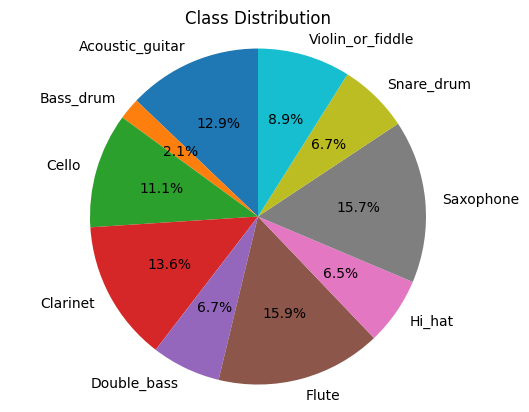

In [13]:
fig,ax=plt.subplots()
ax.set_title("Class Distribution",y=1.00)
ax.pie(class_dist,labels=class_dist.index,autopct='%1.1f%%',shadow=False,startangle=90)
ax.axis('equal')
plt.show()

In [14]:
n_samples=2*int(df['length'].sum()/0.1)
n_samples

23806

In [15]:
prob_dist=class_dist/class_dist.sum()

In [16]:
choices=np.random.choice(class_dist.index,p=prob_dist)

In [17]:
config= Config(mode='conv')

In [18]:
X,y= build_rand_feat()


100%|██████████| 23806/23806 [01:37<00:00, 243.38it/s]


In [19]:
if(config.mode=='conv'):
  y_flat=np.argmax(y,axis=1)
  input_shape=(X.shape[1],X.shape[2],1)
  model=get_conv_model()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 9, 13, 16)         160       
                                                                 
 conv2d_1 (Conv2D)           (None, 9, 13, 32)         4640      
                                                                 
 conv2d_2 (Conv2D)           (None, 9, 13, 64)         18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 9, 13, 128)        73856     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 4, 6, 128)        0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 4, 6, 128)         0         
                                                        

In [20]:
class_weight=compute_class_weight(class_weight='balanced',classes=np.unique(y_flat),y=y_flat)
class_weight_dict = dict(zip(np.unique(y_flat), class_weight))

In [21]:
class_weight_dict

{0: 0.7846407382992748,
 1: 4.53447619047619,
 2: 0.9439333862014274,
 3: 0.746269592476489,
 4: 1.4841645885286783,
 5: 0.6205943691345152,
 6: 1.5378552971576227,
 7: 0.6331382978723404,
 8: 1.521150159744409,
 9: 1.0713771377137713}

Convolutional model fitting

In [22]:
model.fit(X,y,epochs=10,batch_size=32,shuffle=True,class_weight=class_weight_dict,validation_split=0.1)

Epoch 1/10
670/670 [==============================] - 43s 62ms/step - loss: 1.0198 - accuracy: 0.6131 - val_loss: 0.6907 - val_accuracy: 0.7677
Epoch 2/10
670/670 [==============================] - 44s 66ms/step - loss: 0.4924 - accuracy: 0.8126 - val_loss: 0.4030 - val_accuracy: 0.8522
Epoch 3/10
670/670 [==============================] - 43s 64ms/step - loss: 0.3417 - accuracy: 0.8715 - val_loss: 0.3133 - val_accuracy: 0.8967
Epoch 4/10
670/670 [==============================] - 43s 65ms/step - loss: 0.2714 - accuracy: 0.8961 - val_loss: 0.3094 - val_accuracy: 0.8996
Epoch 5/10
670/670 [==============================] - 41s 60ms/step - loss: 0.2345 - accuracy: 0.9102 - val_loss: 0.2460 - val_accuracy: 0.9189
Epoch 6/10
670/670 [==============================] - 40s 59ms/step - loss: 0.2033 - accuracy: 0.9218 - val_loss: 0.3095 - val_accuracy: 0.8879
Epoch 7/10
670/670 [==============================] - 41s 61ms/step - loss: 0.1794 - accuracy: 0.9316 - val_loss: 0.1695 - val_accuracy:

In [23]:
model.save("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/V2/Conv_model.h5")

In [24]:
print(config.step)
print(config.nfilt)
print(config.nfeat)
print(config.nfft)
print(config.rate)
print(config.step)
print(config.min)
print(config.max)

1600
26
13
512
16000
1600
-73.19197018743574
70.48366209252114


Recurrent model fitting

In [25]:
config= Config(mode='time')
X,y= build_rand_feat()


100%|██████████| 23806/23806 [01:38<00:00, 242.19it/s]


In [26]:
if(config.mode=='time'):
  y_flat=np.argmax(y,axis=1)
  input_shape=(X.shape[1],X.shape[2])
  model=get_recurrent_model()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 9, 128)            72704     
                                                                 
 lstm_1 (LSTM)               (None, 9, 128)            131584    
                                                                 
 dropout_1 (Dropout)         (None, 9, 128)            0         
                                                                 
 time_distributed (TimeDistr  (None, 9, 64)            8256      
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 9, 32)            2080      
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 9, 16)           

In [27]:
class_weight=compute_class_weight(class_weight='balanced',classes=np.unique(y_flat),y=y_flat)
class_weight_dict = dict(zip(np.unique(y_flat), class_weight))

In [28]:
model.fit(X,y,epochs=10,batch_size=32,shuffle=True,class_weight=class_weight_dict,validation_split=0.1)

Epoch 1/10
670/670 [==============================] - 26s 33ms/step - loss: 1.8797 - accuracy: 0.2553 - val_loss: 1.5821 - val_accuracy: 0.3738
Epoch 2/10
670/670 [==============================] - 21s 31ms/step - loss: 1.3430 - accuracy: 0.4589 - val_loss: 1.1635 - val_accuracy: 0.5519
Epoch 3/10
670/670 [==============================] - 21s 32ms/step - loss: 1.0424 - accuracy: 0.5895 - val_loss: 0.9649 - val_accuracy: 0.6573
Epoch 4/10
670/670 [==============================] - 21s 32ms/step - loss: 0.8621 - accuracy: 0.6690 - val_loss: 0.7662 - val_accuracy: 0.7350
Epoch 5/10
670/670 [==============================] - 20s 30ms/step - loss: 0.7498 - accuracy: 0.7174 - val_loss: 0.7421 - val_accuracy: 0.7320
Epoch 6/10
670/670 [==============================] - 21s 32ms/step - loss: 0.6695 - accuracy: 0.7493 - val_loss: 0.6245 - val_accuracy: 0.7841
Epoch 7/10
670/670 [==============================] - 21s 31ms/step - loss: 0.6059 - accuracy: 0.7791 - val_loss: 0.6605 - val_accuracy:

In [29]:
model.save("/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/V2/LSTM_model.h5")

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/PGDBA-Project/config_obj.pkl', 'wb') as file:
    pickle.dump(config, file)

In [30]:
print(config.step)
print(config.nfilt)
print(config.nfeat)
print(config.nfft)
print(config.rate)
print(config.step)
print(config.min)
print(config.max)

1600
26
13
512
16000
1600
-72.12846428686261
71.50207567298749
